# Truss Bridge Builder: Geometry → Load Path → Forces → Checks → MIDAS

`civilpy.structural.truss_builder` assembles a complete truss bridge from
typed components.  The invented example: a 137-ft through Pratt with
**non-uniform panels** (shorter end panels) and a **polygonal top chord**,
carrying an **off-center roadway** — the kind of asymmetry real rehab projects
have.

* Panels: 21 + 23.75 ×4 + 21 ft, trusses 21.5 ft apart
* Top chord rises from 26 ft at the first interior points to 29.5 ft
* 22-ft deck shifted 1.25 ft toward one truss, two 11-ft lanes

In [1]:
from civilpy.structural.truss_builder import (
    TrussBridge, TrussSection, Deck, LaneLine,
    TopChord, BottomChord, EndPost, Diagonal, Vertical)

bridge = TrussBridge(
    panel_lengths_ft=[21.0, 23.75, 23.75, 23.75, 23.75, 21.0],
    heights_ft=[None, 26.0, 29.5, 29.5, 29.5, 26.0, None],
    width_ft=21.5, pattern="pratt")
bridge.set_deck(Deck(width_ft=22.0, thickness_in=7.0,
                     wearing_surface_psf=30.0, offset_ft=1.25),
                stringer_offsets_ft=[-8.0, -2.75, 2.75, 8.0])
bridge.add_lane(LaneLine("NB", offset_ft=-4.25, width_ft=11.0))
bridge.add_lane(LaneLine("SB", offset_ft=6.75, width_ft=11.0))
bridge

<TrussBridge 137 ft, 6 panels, 21 members/plane, 4 stringer lines>

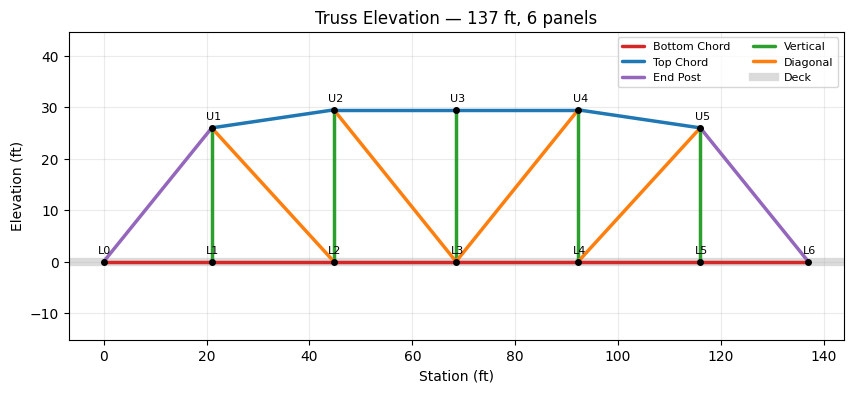

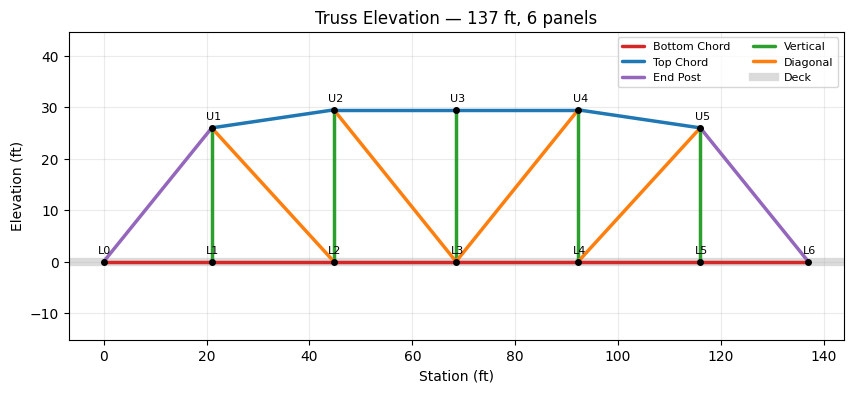

In [2]:
bridge.plot_elevation()

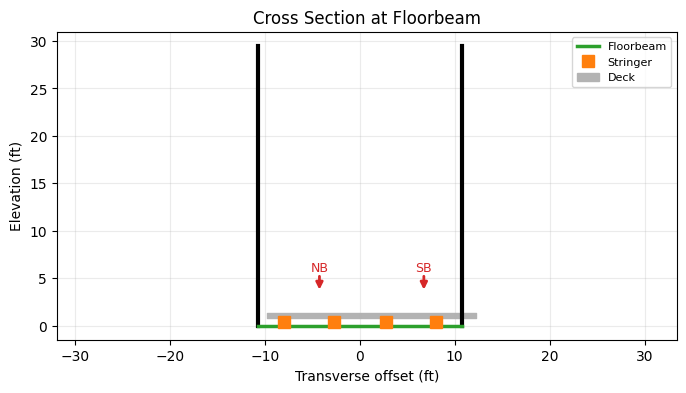

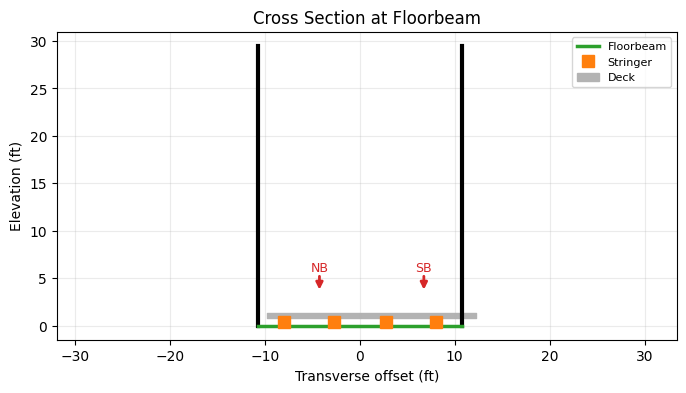

In [3]:
bridge.plot_cross_section()

The full 3-D assembly, drawn from the same node/element tables the MIDAS export sends — both truss planes, floorbeams split at the stringer crossings, stringers, top struts, lane lines, and the deck outline:

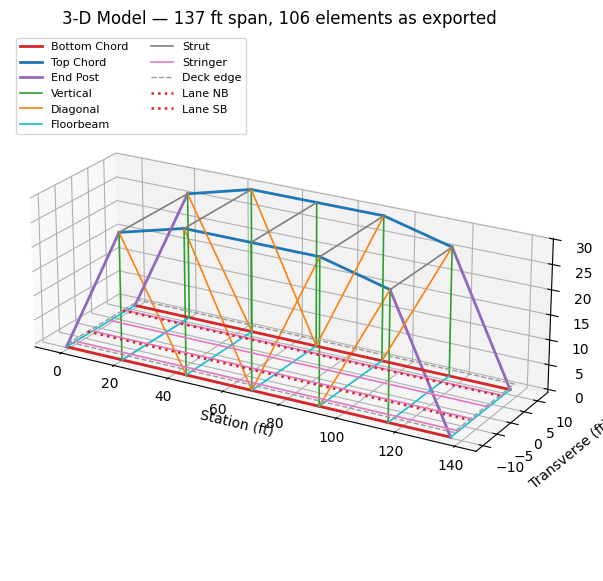

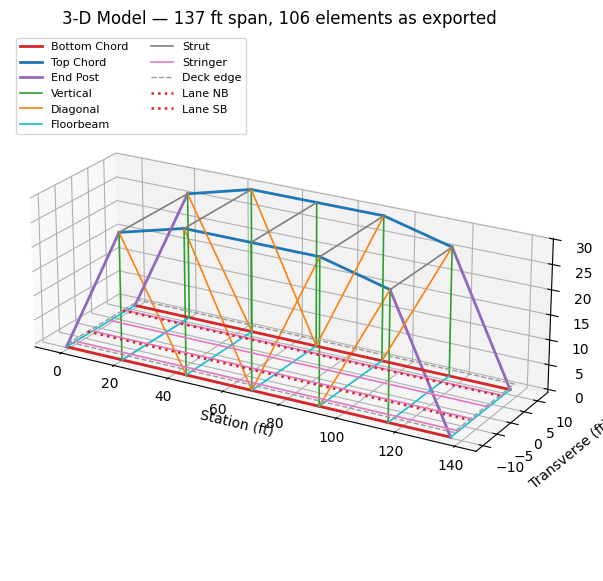

In [4]:
bridge.plot_3d()

## The load path is semantic

Deck area load → stringer tributary widths → floorbeam point loads → plane
loads by floorbeam statics.  The 1.25-ft deck offset loads the far truss
visibly harder:

In [5]:
near = sum(bridge.panel_point_loads("near").values())
far = sum(bridge.panel_point_loads("far").values())
print(f"near truss carries {near:.0f} kips, far truss {far:.0f} kips "
      f"({far / (near + far):.0%} of the deck)")

near truss carries 162 kips, far truss 192 kips (54% of the deck)


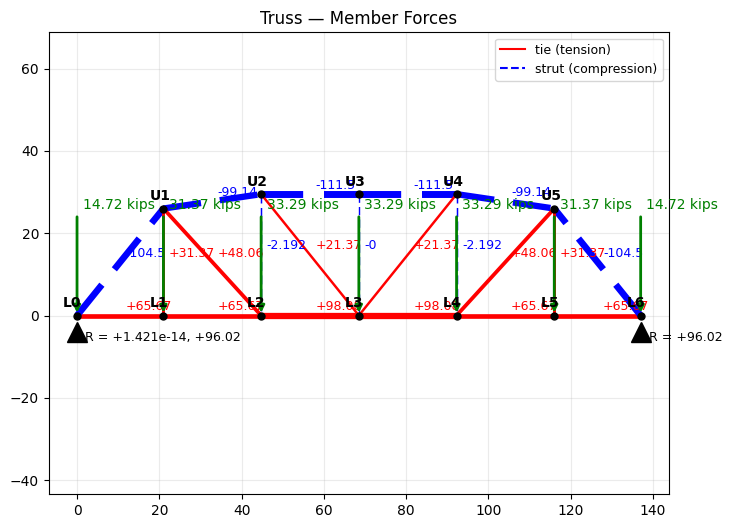

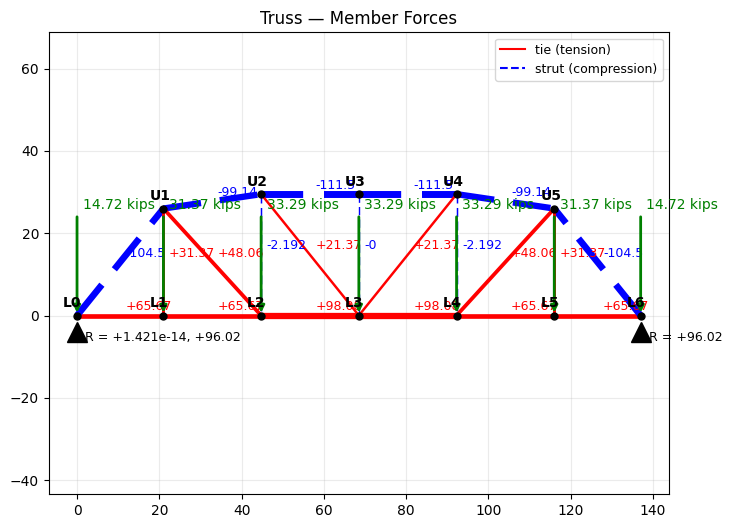

In [6]:
bridge.plot_forces(plane="far")

## Capacity checks route by member type

Assign sections to the typed components; tension members go through 6.8.2.1
(yield + net-section rupture) and compression members through 6.9.4.1.1 with
KL/r from each member's own geometry.

In [7]:
bridge.assign_section(BottomChord, TrussSection(
    "BC 2L8x6", area_in2=16.5, net_area_in2=14.2, r_in=2.55))
bridge.assign_section(TopChord, TrussSection("TC box", 21.0, r_in=3.4))
bridge.assign_section(EndPost, TrussSection("EP box", 19.0, r_in=3.1))
bridge.assign_section(Diagonal, TrussSection(
    "D 2L6x4", 11.0, net_area_in2=9.4, r_in=1.9))
bridge.assign_section(Vertical, TrussSection("V 2L5x3.5", 8.1, r_in=1.6))

for name, check in sorted(bridge.capacity_checks().items()):
    ratio = (check.demand or 0.0) / check.factored_capacity
    print(f"{name:28s} {check.article:9s} "
          f"DCR = {ratio:.2f}")

Bottom Chord L0-L1           6.8.2.1   DCR = 0.09
Bottom Chord L1-L2           6.8.2.1   DCR = 0.09
Bottom Chord L2-L3           6.8.2.1   DCR = 0.13
Bottom Chord L3-L4           6.8.2.1   DCR = 0.13
Bottom Chord L4-L5           6.8.2.1   DCR = 0.09
Bottom Chord L5-L6           6.8.2.1   DCR = 0.09
Diagonal U1-L2               6.8.2.1   DCR = 0.10
Diagonal U2-L3               6.8.2.1   DCR = 0.04
Diagonal U4-L3               6.8.2.1   DCR = 0.04
Diagonal U5-L4               6.8.2.1   DCR = 0.10
End Post L0-U1               6.9.4.1.1 DCR = 0.39
End Post L6-U5               6.9.4.1.1 DCR = 0.39
Top Chord U1-U2              6.9.4.1.1 DCR = 0.17
Top Chord U2-U3              6.9.4.1.1 DCR = 0.19
Top Chord U3-U4              6.9.4.1.1 DCR = 0.19
Top Chord U4-U5              6.9.4.1.1 DCR = 0.17
Vertical U1-L1               6.8.2.1   DCR = 0.08
Vertical U2-L2               6.9.4.1.1 DCR = 0.06
Vertical U3-L3               6.8.2.1   DCR = 0.00
Vertical U4-L4               6.9.4.1.1 DCR = 0.06


## Straight to MIDAS Civil NX

`midas_payloads()` builds every `/db/*` table for the 3-D model — typed
elements, structure groups per component, DC/DW beam loads on the stringers,
and traffic lanes riding the stringer nearest each lane line.  With Civil NX
listening, `bridge.to_midas()` sends it.

In [8]:
payloads = bridge.midas_payloads()
for table, assign in payloads.items():
    print(f"{table:5s} {len(assign):4d} rows")
# one stringer element, for flavor
eid = next(iter(payloads["BMLD"]))
print("\nstringer", eid, "->", payloads["ELEM"][eid])
print("beam loads:", [i["LCNAME"] for i in payloads["BMLD"][eid]["ITEMS"]])

UNIT     1 rows
MATL     1 rows
SECT     6 rows
NODE    52 rows
ELEM   106 rows
CONS     4 rows
GRUP     8 rows
STLD     2 rows
BMLD    24 rows
LLAN     2 rows

stringer 83 -> {'TYPE': 'BEAM', 'MATL': 1, 'SECT': 6, 'NODE': [25, 29], 'ANGLE': 0}
beam loads: ['DC', 'DW']
